In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from imblearn.over_sampling import SMOTE
import optuna
import matplotlib.pyplot as plt

In [4]:
# Load the dataset
df = pd.read_csv(r'C:\Users\khiew\Downloads\FYP Reduced Dataset.csv')

In [5]:
# Drop diseases with less than 1000 instances
disease_counts = df['diseases'].value_counts()
valid_diseases = disease_counts[disease_counts >= 750].index
df = df[df['diseases'].isin(valid_diseases)]

# Assuming that the target variable is 'diseases' and all other variables are input features
X = df.drop('diseases', axis=1)
y = df['diseases']

# Encode the target variable (diseases) if it's a categorical variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
num_classes = len(np.unique(y_train))
input_dim = X_train.shape[1]
print("Number of remaining classes in training set:", len(np.unique(y_train)))
print("Number of rows left:", len(df))

Number of remaining classes in training set: 114
Number of rows left: 114312


In [6]:
# Optuna objective function
def objective(trial):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    # Suggest hyperparameters
    n_layers = trial.suggest_int('n_layers', 1, 3)
    for i in range(n_layers):
        num_units = trial.suggest_int(f'n_units_{i}', 64, 256, step=64)
        activation = trial.suggest_categorical(f'activation_{i}', ['relu', 'tanh'])
        model.add(layers.Dense(num_units, activation=activation))
        dropout_rate = trial.suggest_float(f'dropout_rate_{i}', 0.2, 0.5)
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation='softmax'))

    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(X_train, y_train,
                        validation_split=0.2,
                        epochs=10,
                        batch_size=trial.suggest_categorical('batch_size', [32, 64, 128]),
                        verbose=0)

    val_accuracy = max(history.history['val_accuracy'])
    return val_accuracy

In [7]:
# Create Optuna study for optimization with persistent storage
study = optuna.create_study(
    direction='maximize',  # Assuming you are maximizing accuracy
    study_name="DNN_diseases_symptoms_dropextremelymore750withoutSMOTE_study", 
    storage=r"sqlite:///C:/Users/khiew/Downloads/dnn.db", 
    load_if_exists=True  # Load the study if it already exists, to resume from the last trial
)

# Optimize the study with your objective function, you can adjust the n_trials as needed
study.optimize(objective, n_trials=20)
# Print the best trial and hyperparameters
print("\nBest Trial:")
print(study.best_trial)
print("Best Hyperparameters:")
print(study.best_trial.params)

[I 2025-04-25 02:01:14,687] A new study created in RDB with name: DNN_diseases_symptoms_dropextremelymore750withoutSMOTE_study
[I 2025-04-25 02:01:33,423] Trial 0 finished with value: 0.4813012480735779 and parameters: {'n_layers': 3, 'n_units_0': 64, 'activation_0': 'relu', 'dropout_rate_0': 0.3482627583235137, 'n_units_1': 64, 'activation_1': 'tanh', 'dropout_rate_1': 0.3847836579463273, 'n_units_2': 192, 'activation_2': 'relu', 'dropout_rate_2': 0.38161740012823964, 'learning_rate': 0.000987935430923719, 'batch_size': 64}. Best is trial 0 with value: 0.4813012480735779.
[I 2025-04-25 02:02:01,292] Trial 1 finished with value: 0.4794969856739044 and parameters: {'n_layers': 2, 'n_units_0': 64, 'activation_0': 'tanh', 'dropout_rate_0': 0.4647676083755598, 'n_units_1': 128, 'activation_1': 'relu', 'dropout_rate_1': 0.4264926258898156, 'learning_rate': 0.006292331433229786, 'batch_size': 32}. Best is trial 0 with value: 0.4813012480735779.
[I 2025-04-25 02:02:12,746] Trial 2 finished wi


Best Trial:
FrozenTrial(number=12, state=TrialState.COMPLETE, values=[0.49425914883613586], datetime_start=datetime.datetime(2025, 4, 25, 2, 4, 46, 157908), datetime_complete=datetime.datetime(2025, 4, 25, 2, 5, 4, 82652), params={'n_layers': 2, 'n_units_0': 192, 'activation_0': 'tanh', 'dropout_rate_0': 0.28884482184157134, 'n_units_1': 256, 'activation_1': 'tanh', 'dropout_rate_1': 0.3077978140421515, 'learning_rate': 0.00011059658306756647, 'batch_size': 64}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_layers': IntDistribution(high=3, log=False, low=1, step=1), 'n_units_0': IntDistribution(high=256, log=False, low=64, step=64), 'activation_0': CategoricalDistribution(choices=('relu', 'tanh')), 'dropout_rate_0': FloatDistribution(high=0.5, log=False, low=0.2, step=None), 'n_units_1': IntDistribution(high=256, log=False, low=64, step=64), 'activation_1': CategoricalDistribution(choices=('relu', 'tanh')), 'dropout_rate_1': FloatDistribution(high=0.5, log=

Epoch 1/20
1144/1144 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1523 - loss: 4.1038 - val_accuracy: 0.4400 - val_loss: 2.3421
Epoch 2/20
1144/1144 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4100 - loss: 2.2124 - val_accuracy: 0.4815 - val_loss: 1.7750
Epoch 3/20
1144/1144 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4449 - loss: 1.8269 - val_accuracy: 0.4875 - val_loss: 1.6392
Epoch 4/20
1144/1144 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4545 - loss: 1.7229 - val_accuracy: 0.4904 - val_loss: 1.5880
Epoch 5/20
1144/1144 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4562 - loss: 1.6852 - val_accuracy: 0.4916 - val_loss: 1.5620
Epoch 6/20
1144/1144 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4622 - loss: 1.6416 - val_accuracy: 0.4909 - val_loss: 1.5481
Epoch 7/20
1144/1144 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4591 - loss: 1.6482 - val_accuracy: 0.4929 - val_loss: 1.5373
Epoch 8/20
1144/1144 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4590 - loss: 1.6377 - 

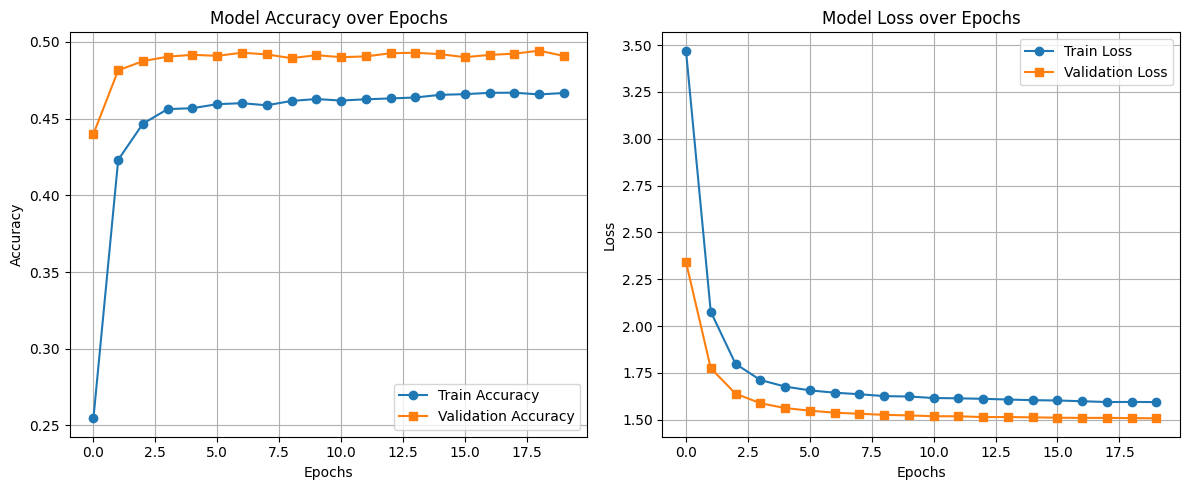

In [8]:
# Load Optuna study
study = optuna.load_study(
    study_name="DNN_diseases_symptoms_dropextremelymore750withoutSMOTE_study",
    storage="sqlite:///C:/Users/khiew/Downloads/dnn.db"
)

# Get best parameters
best_params = study.best_trial.params

# Rebuild model using best parameters
best_model = keras.Sequential()
best_model.add(layers.Input(shape=(input_dim,)))

for i in range(best_params['n_layers']):
    best_model.add(layers.Dense(best_params[f'n_units_{i}'], activation=best_params[f'activation_{i}']))
    best_model.add(layers.Dropout(best_params[f'dropout_rate_{i}']))

best_model.add(layers.Dense(num_classes, activation='softmax'))

best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fit the model and save training history
history = best_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    verbose=1
)

# ===========================
# Plotting Training Lifecycle
# ===========================

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import classification_report

y_pred_test = np.argmax(best_model.predict(X_test), axis=1)
print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_))


715/715 ━━━━━━━━━━━━━━━━━━━━ 1s 673us/step
Classification Report on Test Set:
                                              precision    recall  f1-score   support

                           actinic keratosis       0.00      0.00      0.00       192
                         acute bronchiolitis       0.40      0.66      0.50       245
                            acute bronchitis       0.68      0.42      0.52       275
                          acute bronchospasm       0.74      0.46      0.57       174
                         acute kidney injury       0.93      0.73      0.82       202
                          acute pancreatitis       1.00      0.71      0.83       245
                             acute sinusitis       0.32      0.24      0.28       188
                       acute stress reaction       0.98      0.77      0.87       158
                                     allergy       0.99      0.61      0.76       175
                                      angina       0.60      

c:\Users\khiew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\khiew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\khiew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo